In [1]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

   row.names  sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  \
0          1  160    12.00  5.73      23.11  Present     49    25.30    97.20   
1          2  144     0.01  4.41      28.61   Absent     55    28.87     2.06   
2          3  118     0.08  3.48      32.28  Present     52    29.14     3.81   
3          4  170     7.50  6.41      38.03  Present     51    31.99    24.26   
4          5  134    13.60  3.50      27.78  Present     60    25.99    57.34   

   age  chd  
0   52    1  
1   63    1  
2   46    0  
3   58    1  
4   49    1  


,row.names,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
row.names,1.000000,0.171583,-0.044813,-0.064014,0.033851,0.019941,-0.147769,-0.026758,0.088825,-0.014064,NaN
sbp,0.171583,1.000000,0.212247,0.158296,0.356500,0.085645,-0.057454,0.238067,0.140096,0.388771,NaN
tobacco,-0.044813,0.212247,1.000000,0.158905,0.286640,0.088601,-0.014608,0.124529,0.200813,0.450330,NaN
ldl,-0.064014,0.158296,0.158905,1.000000,0.440432,0.161353,0.044048,0.330506,-0.033403,0.311799,NaN
adiposity,0.033851,0.356500,0.286640,0.440432,1.000000,0.181721,-0.043144,0.716556,0.100330,0.625954,NaN
famhist,0.019941,0.085645,0.088601,0.161353,0.181721,1.000000,0.044809,0.115595,0.080520,0.239667,NaN
typea,-0.147769,-0.057454,-0.014608,0.044048,-0.043144,0.044809,1.000000,0.074006,0.039498,-0.102606,NaN
obesity,-0.026758,0.238067,0.124529,0.330506,0.716556,0.115595,0.074006,1.000000,0.051620,0.291777,NaN
alcohol,0.088825,0.140096,0.200813,-0.033403,0.100330,0.080520,0.039498,0.051620,1.000000,0.101125,NaN
age,-0.014064,0.388771,0.450330,0.311799,0.625954,0.239667,-0.102606,0.291777,0.101125,1.000000,NaN


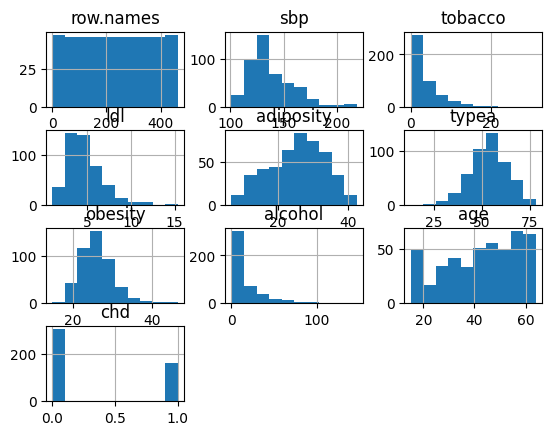

In [2]:
# Dataset
import pandas as pd
file_path = "SAheart.csv"  # Replace with your CSV file path
df = pd.read_csv(file_path, sep=",", decimal=".")
print(df.head())
df.hist()

df["famhist"] = df["famhist"].map({
        "Absent": 0,
        "Present": 1,
    })
df["chd"] = df["chd"].map({
    "No": 0,
    "Si": 1,
})
df.corr()

Characteristics The ten features are defined as follows:

sbp: systolic blood pressure

tobacco: cumulative tobacco (kg)

ldl: low density lipoprotein cholesterol

adiposity: the amount or distribution of fat tissue (adipose tissue) in the body

famhist: family history of heart disease (Present=1, Absent=0)

typea: type-A behavior

obesity: medical condition characterized by excessive body fat that may impair health

alcohol: current alcohol consumption

age: age at onset

chd: coronary heart disease (yes=1 or no=0)


In [3]:
# Include expert knowledge
from pgmpy.estimators import ExpertKnowledge
df = df.drop(columns=["obesity", "row.names"], errors="ignore")
cols = list(df.columns)

# Forbid arrows OUT of chd: chd is the target variable
forbidden = [("chd", col) for col in cols if col != "chd"]

expert_knowledge = ExpertKnowledge(
    temporal_order=[
        ["age", "famhist"],   # upstream/background variables
        [c for c in cols if c not in ["age", "famhist", "chd"]],
        ["chd"]               # outcome last
    ],
    #forbidden_edges=forbidden,
)

In [4]:
import pandas as pd
#from pgmpy.causal_discovery import PC
from pgmpy.estimators import PC
# To see where the bug is
from pgmpy.estimators import PC
import inspect
print(inspect.getfile(PC))
import networkx as nx
import matplotlib.pyplot as plt

def learn_dependency_graph(file_path,
                           max_cond_vars=2,
                           significance_level=0.01,
                           discretize_cont_cols = False,
                           expert_knowledge = None,
                           enforce_expert_knowledge = False,
                           debug = False):
    # Step 1: Load dataset
    data = pd.read_csv(file_path)

    # Drop index column if present
    data = data.drop(columns=["row.names"], errors="ignore")

    data["famhist"] = data["famhist"].map({
        "Absent": 0,
        "Present": 1,
    })
    # chd may already be 0/1 ints; only remap if it contains strings
    if data["chd"].dtype == object:
        data["chd"] = data["chd"].map({"No": 0, "Si": 1})

    # Obesity and adiposity are kind of similar, so let's keep one
    data = data.drop(columns=["obesity"])

    # Optional: Discretize continuous columns
    if discretize_cont_cols:
        for col in data.select_dtypes(include=['float64', 'int64']).columns:
            data[col] = pd.qcut(data[col], q=4, duplicates='drop', labels=False)

    data.dropna(inplace=True)

    # Step 2: Estimate DAG with PC algorithm

    # Old version
    pc = PC(data)
    model = pc.estimate(significance_level=significance_level,
                        max_cond_vars=max_cond_vars,
                        #ci_test="chi_square" if discretize_cont_cols else "pearsonr",
                        #variant = "stable",
                        expert_knowledge=expert_knowledge,
                        enforce_expert_knowledge=enforce_expert_knowledge
                        #output = "cpdag"
                        )

    # New libary version
    # pc = PC(
    #     significance_level=significance_level,
    #     max_cond_vars=max_cond_vars,
    #     #ci_test="chi_square" if discretize_cont_cols else "pearsonr",
    #     #variant = "stable",
    #     expert_knowledge=expert_knowledge,
    #     enforce_expert_knowledge=enforce_expert_knowledge
    # )
    # pc.fit(data)
    # model = pc.causal_graph_

    # Step 3: Visualize the DAG using edges directly
    nx_graph = nx.DiGraph(model.edges())
    plt.figure(figsize=(10, 7))
    pos = nx.circular_layout(nx_graph)

    # Color nodes: red for 'chd', lightblue for others
    node_colors = ['red' if node == 'chd' else 'lightblue' for node in nx_graph.nodes()]

    nx.draw(nx_graph, pos, with_labels=True, node_size=2000, node_color=node_colors,
            font_size=10, font_weight="bold", arrowsize=20)
    plt.title("Dependency Graph Learned using PC Algorithm")
    plt.show()

    return model

# PC algorithm: This one works without the bug in PC
# learned_model = learn_dependency_graph(file_path,
#                                        max_cond_vars=4,
#                                        significance_level=0.01,
#                                        expert_knowledge=expert_knowledge,
#                                        enforce_expert_knowledge=True)

C:\Users\alexa\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\pgmpy\estimators\PC.py


  0%|          | 0/2 [00:00<?, ?it/s]

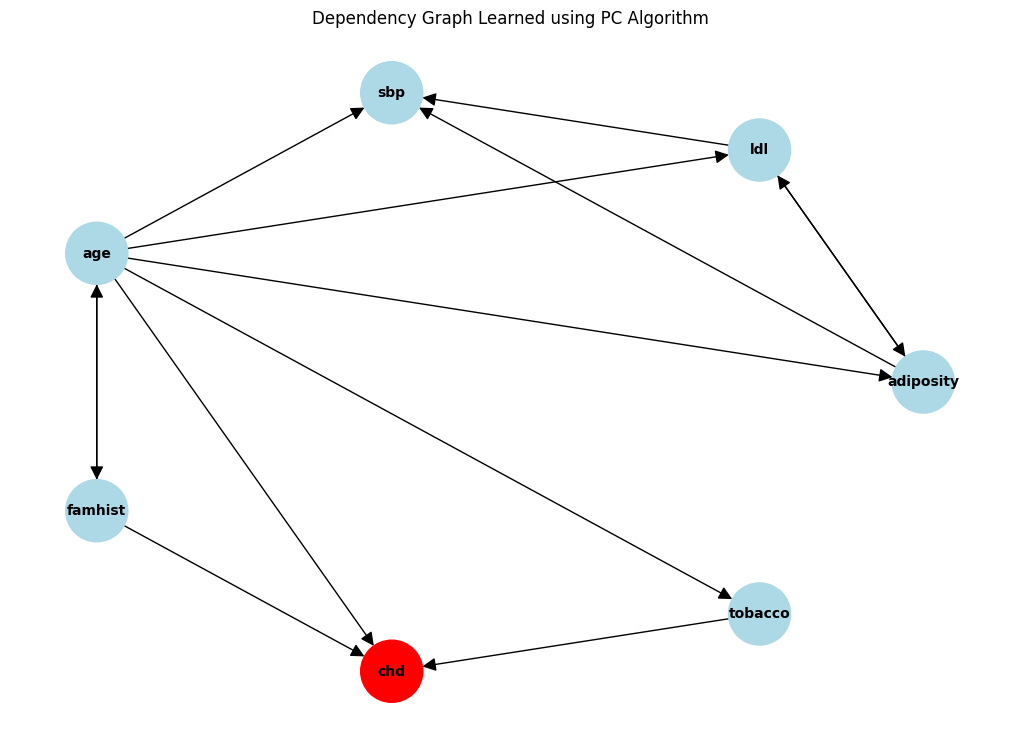

In [5]:
# This one only works with the fix
learned_model = learn_dependency_graph(file_path,
                                       max_cond_vars=2,
                                       significance_level=0.01,
                                       expert_knowledge=expert_knowledge,
                                       enforce_expert_knowledge=True)